# Lateral Inhibition and Winner-Take-All Networks

Simulations of lateral-inhibition networks and winner-take-all dynamics, showing how mutual inhibition sharpens activity and selects a single winning unit.

## SETTING

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Simple Lateral Inhibition

In [2]:
# FRAGMENT 4.2, 4.3
DIMENSIONALITY = 80
UPPER_LIMIT = 60
LOWER_LIMIT = 0
NUMBER_OF_ITERATIONS = 50
EPSILON = 0.1

In [3]:
# FRAGMENT 4.4
def initialize_state_vector():
  initial = np.zeros(DIMENSIONALITY)
  initial[0:20] = 10   # Neurons 1-20 (0-19 index)
  initial[20:60] = 40  # Neurons 21-60 (20-59 index)
  initial[60:80] = 10  # Neurons 61-80 (60-79 index)
  return initial

In [29]:
# FRAGMENT 4.5
def compute_lateral_inhibition(initial_rates, max_strength, length_constant):
  state = initial_rates.copy()
  indices = np.arange(DIMENSIONALITY)

  # weight matrix
  weights = np.zeros((DIMENSIONALITY, DIMENSIONALITY))
  for i in range(DIMENSIONALITY):
    diff = np.abs(indices - i)
    dist = np.minimum(diff, DIMENSIONALITY - diff)
    # Gaussian inhibitory profile
    weights[i] = -max_strength * np.exp(-(dist**2) / (2 * length_constant**2))
    weights[i, i] = 0

  for _ in range(NUMBER_OF_ITERATIONS):
    inhibition = np.dot(weights, state)
    # update
    delta = initial_rates + inhibition - state
    state = state + EPSILON * delta
    state = np.clip(state, LOWER_LIMIT, UPPER_LIMIT)

  return state

In [27]:
def plot_figure(initial, final, max_inh, fig_num):
  indices = np.arange(12, 31) # zooming into neurons 12-30
  plt.figure(figsize=(5, 7))
  plt.scatter(initial[11:30], indices, marker='+', color='black', label='Initial (+)')
  plt.scatter(final[11:30], indices, marker='*', color='black', label='Final (*)')

  plt.title(f"Figure {fig_num}: Max Inhibition {max_inh}")
  plt.xlabel("Firing Rate: Spikes/Second")
  plt.ylabel("Neuron Index")
  plt.xlim(0, 50)
  plt.ylim(11, 31)
  plt.gca().invert_yaxis()
  plt.grid(True, linestyle=':', alpha=0.6)
  plt.legend()
  plt.show()

### Experiment 1

Simple Lateral Inhibition
Initial state: +.  Final state: *
Parameters: Length Constant: 2.00 Maximum Inhibition: 0.10


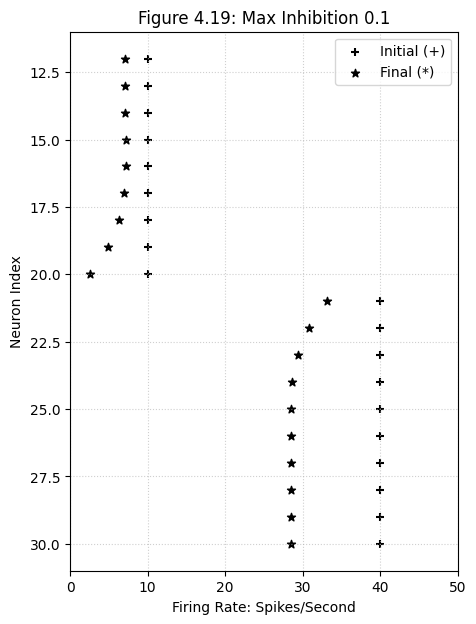

In [30]:
initial = initialize_state_vector()
final = compute_lateral_inhibition(initial, max_strength=0.10, length_constant=2.00)
print('Simple Lateral Inhibition')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 2.00 Maximum Inhibition: 0.10')
plot_figure(initial, final, 0.10, "Experiment 1")

### Experiment 2

Simple Lateral Inhibition
Initial state: +.  Final state: *
Parameters: Length Constant: 2.00 Maximum Inhibition: 0.20


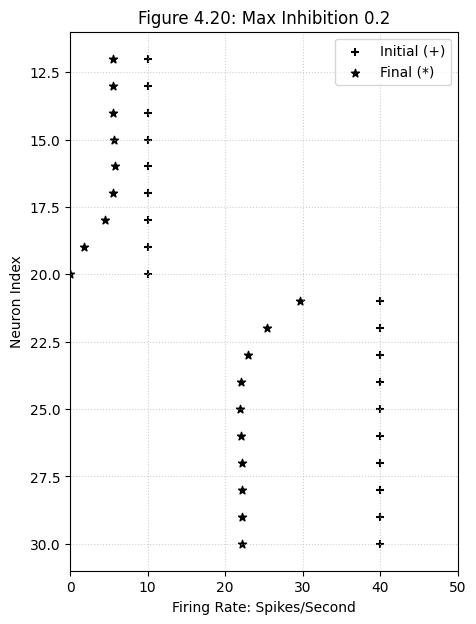

In [22]:
initial = initialize_state_vector()
final = compute_lateral_inhibition(initial, max_strength=0.20, length_constant=2.00)
print('Simple Lateral Inhibition')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 2.00 Maximum Inhibition: 0.20')
plot_figure(initial, final, 0.20, "Experiment 2")

### Experiment 3

Simple Lateral Inhibition
Initial state: +.  Final state: *
Parameters: Length Constant: 2.00 Maximum Inhibition: 0.50


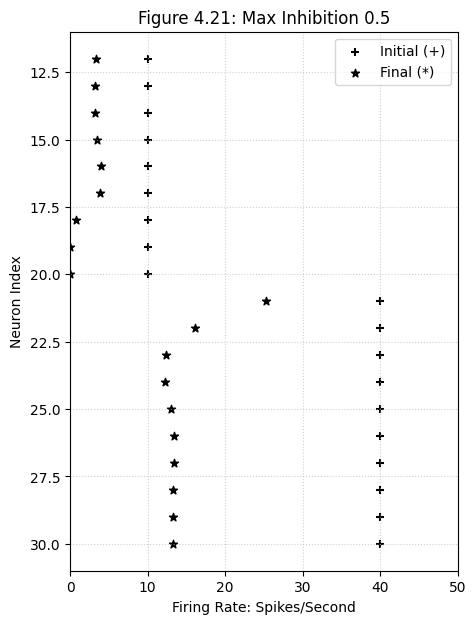

In [23]:
initial = initialize_state_vector()
final = compute_lateral_inhibition(initial, max_strength=0.50, length_constant=2.00)
print('Simple Lateral Inhibition')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 2.00 Maximum Inhibition: 0.50')
plot_figure(initial, final, 0.50, "Experiment 3")

### Experiment 4

Simple Lateral Inhibition
Initial state: +.  Final state: *
Parameters: Length Constant: 2.00 Maximum Inhibition: 1.00


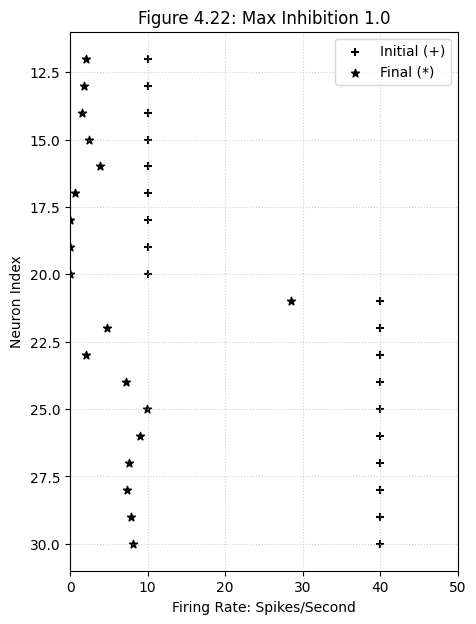

In [24]:
initial = initialize_state_vector()
final = compute_lateral_inhibition(initial, max_strength=1.00, length_constant=2.00)
print('Simple Lateral Inhibition')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 2.00 Maximum Inhibition: 1.00')
plot_figure(initial, final, 1.00, "Experiment 4")

### Experiment 5

Simple Lateral Inhibition
Initial state: +.  Final state: *
Parameters: Length Constant: 2.00 Maximum Inhibition: 2.00


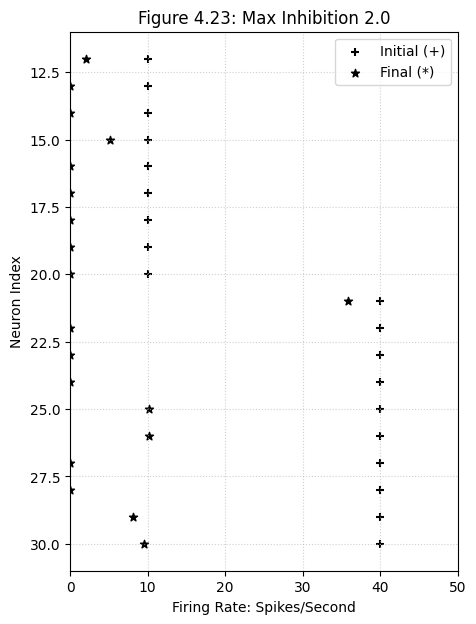

In [25]:
initial = initialize_state_vector()
final = compute_lateral_inhibition(initial, max_strength=2.00, length_constant=2.00)
print('Simple Lateral Inhibition')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 2.00 Maximum Inhibition: 2.00')
plot_figure(initial, final, 2.00, "Experiment 5")

## Winner Take-All Network

In [31]:
def initialize_single_peak(background=0):
    initial = np.full(DIMENSIONALITY, background, dtype=float)
    for i in range(DIMENSIONALITY):
        dist = abs(i - 19)
        val = 50 - (dist * 5)
        if val > background:
            initial[i] = val
    return initial

In [32]:
def initialize_twin_peaks():
  initial = np.zeros(DIMENSIONALITY)
  for i in range(DIMENSIONALITY):
    p1 = 40 - abs(i - 20) * 5
    p2 = 30 - abs(i - 14) * 5
    initial[i] = max(0, p1, p2)
  return initial

### Experiment 1

Winner-Take-All Network
Initial state: +.  Final state: *
Parameters: Length Constant: 10.00 Maximum Inhibition: 1.00


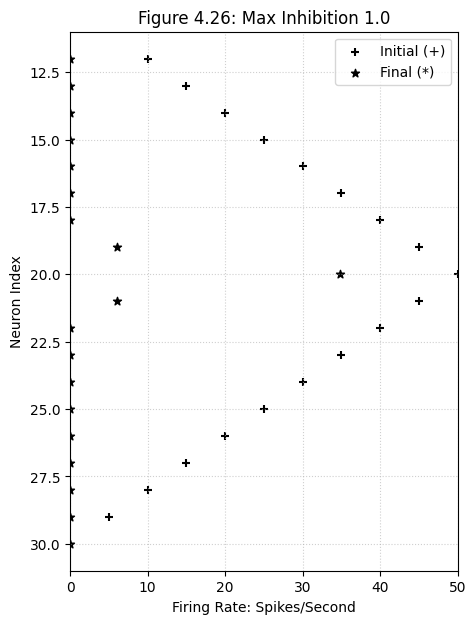

Single Peak, No Bias Light Level


In [33]:
initial = initialize_single_peak(background=0)
final = compute_lateral_inhibition(initial, max_strength=1.0, length_constant=10.0)
print('Winner-Take-All Network')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 10.00 Maximum Inhibition: 1.00')
plot_figure(initial, final, 1.0, "Experiment 1")
print('Single Peak, No Bias Light Level')

### Experiment 2

Winner-Take-All Network
Initial state: +.  Final state: *
Parameters: Length Constant: 10.00 Maximum Inhibition: 1.00


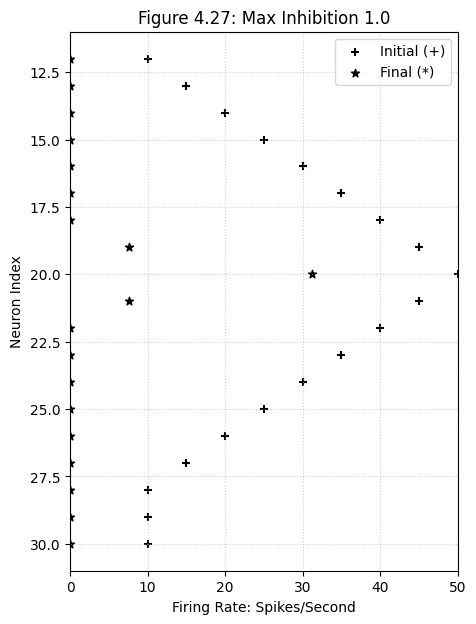

Single Peak, Bias Light Level


In [34]:
initial = initialize_single_peak(background=10)
final = compute_lateral_inhibition(initial, max_strength=1.0, length_constant=10.0)
print('Winner-Take-All Network')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 10.00 Maximum Inhibition: 1.00')
plot_figure(initial, final, 1.0, "Experiment 2")
print('Single Peak, Bias Light Level')

### Experiment 3

Winner-Take-All Network
Initial state: +.  Final state: *
Parameters: Length Constant: 10.00 Maximum Inhibition: 1.00


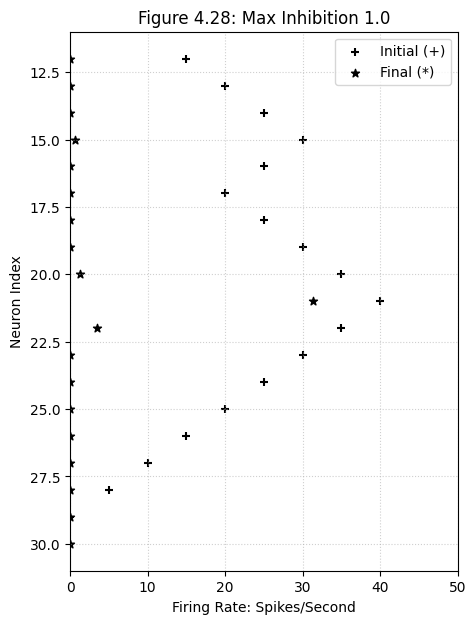

Twin Peaks, Inhibition: 1.0


In [35]:
initial = initialize_twin_peaks()
final_428 = compute_lateral_inhibition(initial, 1.0, 10.0)
print('Winner-Take-All Network')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 10.00 Maximum Inhibition: 1.00')
plot_figure(initial, final_428, 1.0, "Experiment 3")
print('Twin Peaks, Inhibition: 1.0')

### Experiment 4

Winner-Take-All Network
Initial state: +.  Final state: *
Parameters: Length Constant: 10.00 Maximum Inhibition: 2.00


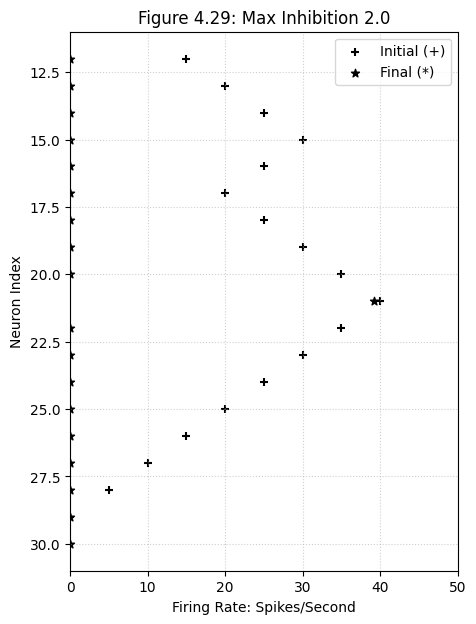

Twin Peaks, Inhibition: 2.0


In [36]:
initial = initialize_twin_peaks()
final_429 = compute_lateral_inhibition(initial, 2.0, 10.0)
print('Winner-Take-All Network')
print('Initial state: +.  Final state: *')
print(f'Parameters: Length Constant: 10.00 Maximum Inhibition: 2.00')
plot_figure(initial, final_429, 2.0, "Experiment 4")
print('Twin Peaks, Inhibition: 2.0')